In [14]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)


              name
0      db_customer
1  db_subscription
2       db_support


In [15]:
for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [16]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [17]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [22]:
df_db_customer.rename(columns = {'name' : 'customer_name'})

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [26]:
#df_db_customer .drop(df_db_customer.columns[-2:],axis=1) 
df_db_customer.drop(columns=['interests','pincode'],inplace = True)


In [32]:
pd.to_datetime(df_db_customer['dob'])

0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[us]

In [33]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [34]:
df

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [35]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [38]:
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})

In [39]:
df_db_customer['gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [40]:
 df_db_customer['country'].isnull()

0     False
1     False
2     False
3     False
4     False
5      True
6     False
7     False
8      True
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: country, dtype: bool

In [42]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [44]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [45]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

In [47]:
df_db_customer['country']= df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [48]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [50]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [51]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [52]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

              name
0      db_customer
1  db_subscription
2       db_support
Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [6]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [7]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


In [8]:
import pandas as pd
import numpy as np
import sqlite3

In [9]:
conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

In [10]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [11]:
for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df

conn.close()

In [12]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [15]:
(df_db_subscription
    .merge(df_db_customer,on ='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

                  

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,col_1,comment
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,Maharashtra,Male,1982-04-12 00:00:00,travel,None,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23 00:00:00,NaN,None,2024-08-28 00:00:00,N,60.0,None,service issue
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23 00:00:00,NaN,None,2024-08-28 00:00:00,Y,10.0,None,demaned refund
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,Delhi,Female,1978-02-15 00:00:00,movie,None,NaN,NaN,NaN,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,Nagaland,Male,2001-08-30 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05 00:00:00,drama,None,2024-01-20 00:00:00,Y,20.0,None,NaN
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaN,NaN,17.99,720,...,Delhi,Women,1988-12-10 00:00:00,NaN,None,2025-03-18 00:00:00,N,90.0,None,guidance to renew
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21 00:00:00,NaN,None,2024-11-01 00:00:00,N,30.0,None,NaN
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaN,NaN,22.99,1840,...,Rajasthan,Male,1999-03-14 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaN,NaN,13.99,240,...,Kathmandu,Women,1985-07-07 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN


In [16]:
df_db_subscription.shape

(21, 11)

In [18]:
df.shape

(9, 6)

In [19]:
df.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [22]:
df_db_subscription['customerid'].nunique()

21

In [23]:
df_db_customer['customerid'].nunique()

21

In [25]:
df_db_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [27]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [31]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [32]:
(df_db_subscription
    .merge(df_db_customer,on ='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,interests,pincode,complaint_date,escalations,csat_score,col_1,comment,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,Male,1982-04-12 00:00:00,travel,None,NaN,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23 00:00:00,NaN,None,2024-08-28 00:00:00,Y,10.0,None,demaned refund,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,Female,1978-02-15 00:00:00,movie,None,NaN,NaN,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,Male,2001-08-30 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05 00:00:00,drama,None,2024-01-20 00:00:00,Y,20.0,None,NaN,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaN,NaN,17.99,720,...,Women,1988-12-10 00:00:00,NaN,None,2025-03-18 00:00:00,N,90.0,None,guidance to renew,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Female,1976-09-21 00:00:00,NaN,None,2024-11-01 00:00:00,N,30.0,None,NaN,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaN,NaN,22.99,1840,...,Male,1999-03-14 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaN,NaN,13.99,240,...,Women,1985-07-07 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaN,NaN,6.99,335,...,Male,1993-10-29 00:00:00,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
df.shape

(9, 7)

In [35]:
df.to_csv('exported_churn_data.csv',index=False)

In [36]:
df.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment', 'complaint_count'],
      dtype='str')

In [39]:
print(df.columns)

Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment', 'complaint_count'],
      dtype='str')


In [43]:
print(df.columns.tolist())

['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment', 'complaint_count']


In [44]:
df.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment,complaint_count
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue,2
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund,2
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN,1


In [45]:
df_db_subscription.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='str')

In [46]:
import numpy as np

df_db_subscription["churn_flag"] = np.where(
    df_db_subscription["cancellation_date"].notna(),
    1,
    0
)

In [47]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [12]:
%whos

Interactive namespace is empty.


In [13]:
import pandas as pd
import numpy as np
import sqlite3

In [14]:
conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

In [16]:
df_db_subscription["churn_flag"] = (
    df_db_subscription["cancellation_date"].notna().astype(int)
)

In [17]:
churn_rate = df_db_subscription["churn_flag"].mean() * 100
print("Churn Rate =", round(churn_rate, 2), "%")

Churn Rate = 28.57 %


In [18]:
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [20]:
churn_by_plan = (
    df_db_subscription
    .groupby("plan_type")["churn_flag"]
    .mean() * 100
)

print(round(churn_by_plan, 2))
round(df_db_subscription.groupby("plan_type")["churn_flag"].mean() * 100, 2)

plan_type
Basic       60.00
Premium     14.29
Standard    22.22
Name: churn_flag, dtype: float64


plan_type
Basic       60.00
Premium     14.29
Standard    22.22
Name: churn_flag, dtype: float64

In [23]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

df_db_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_db_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)

conn.close()

In [24]:
df_db_subscription["churn_flag"] = (
    df_db_subscription["cancellation_date"].notna().astype(int)
)

In [25]:
df = pd.merge(
    df_db_customer,
    df_db_subscription,
    on="customerid",
    how="inner"
)

In [26]:
result = (
    df.groupby("state")
      .agg(
          Churn_Rate=("churn_flag", "mean"),
          Total_Revenue=("monthly_charges", "sum")
      )
      .reset_index()
)

result["Churn_Rate"] = round(result["Churn_Rate"] * 100, 2)

print(result)

           state  Churn_Rate  Total_Revenue
0          Delhi       25.00          52.96
1      Karnataka      100.00          20.98
2      Kathmandu        0.00          20.98
3    Maharashtra        0.00          50.97
4      Meghalaya       66.67          42.97
5       Nagaland        0.00          22.99
6      Rajasthan        0.00          36.98
7      Telangana       50.00          30.98
8  Uttar Pradesh        0.00         115.98


In [27]:
result = (
    df_db_subscription
    .groupby("subscription_type")
    .agg(
        Churn_Rate=("churn_flag", "mean"),
        Total_Revenue=("monthly_charges", "sum"),
        User_Count=("customerid", "count")
    )
    .reset_index()
)

result["Churn_Rate"] = round(result["Churn_Rate"] * 100, 2)

print(result)

  subscription_type  Churn_Rate  Total_Revenue  User_Count
0           Organic        0.00         145.91           9
1              Paid       16.67         174.94           6
2          Refferal       83.33          74.94           6


In [28]:
df.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag'],
      dtype='str')

In [29]:
df['monthly_charges'].mean()

np.float64(18.847142857142856)

In [31]:
pd.Timestamp.today()

Timestamp('2026-07-07 10:05:29.661106')

In [32]:
df_db_customer["Age"] = (
    (pd.Timestamp.today() - pd.to_datetime(df_db_customer["dob"])).dt.days // 365
)

In [35]:
df_db_subscription["subscription_start_date"] = pd.to_datetime(
    df_db_subscription["subscription_start_date"],
    errors="coerce"
)

In [36]:
today = pd.Timestamp.today()

df_db_subscription["tenure_months"] = (
    (today - df_db_subscription["subscription_start_date"]).dt.days / 30.44
)

In [37]:
avg_tenure = df_db_subscription["tenure_months"].mean()

print("Average Customer Tenure =", round(avg_tenure, 2), "months")

Average Customer Tenure = 55.49 months


In [38]:
revenue_loss = df_db_subscription.loc[
    df_db_subscription["churn_flag"] == 1,
    "monthly_charges"
].sum()

print("Revenue Loss from Churned Users = $", round(revenue_loss, 2))

Revenue Loss from Churned Users = $ 73.94


In [39]:
revenue_loss_plan = (
    df_db_subscription[df_db_subscription["churn_flag"] == 1]
    .groupby("plan_type")["monthly_charges"]
    .sum()
    .reset_index(name="Revenue_Loss")
)

print(revenue_loss_plan)

  plan_type  Revenue_Loss
0     Basic         38.97
1   Premium         12.99
2  Standard         21.98


In [40]:
revenue_loss_sub = (
    df_db_subscription[df_db_subscription["churn_flag"] == 1]
    .groupby("subscription_type")["monthly_charges"]
    .sum()
    .reset_index(name="Revenue_Loss")
)

print(revenue_loss_sub)

  subscription_type  Revenue_Loss
0              Paid         12.99
1          Refferal         60.95


In [43]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

df_db_support = pd.read_sql("SELECT * FROM db_support", conn)

conn.close()

In [44]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [45]:
df_db_support["escalations"].value_counts()

escalations
Y    5
N    4
Name: count, dtype: int64

In [47]:
print("Escalated Cases:", (df_db_support["escalations"] == "Y").sum())
print("Total Cases:", len(df_db_support))

Escalated Cases: 5
Total Cases: 9


In [50]:
print(df_db_support.columns.tolist())

['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [51]:
avg_complaints = df_db_support["col_1"].mean()
print("Average Complaints per Customer =", round(avg_complaints, 2))

Average Complaints per Customer = nan


In [52]:
df_db_support["col_1"].isna().sum()

np.int64(9)

In [53]:
total_complaints = len(df_db_support)
total_customers = df_db_support["customerid"].nunique()

avg_complaints = total_complaints / total_customers

print("Total Complaints:", total_complaints)
print("Total Customers:", total_customers)
print("Average Complaints per Customer:", round(avg_complaints, 2))

Total Complaints: 9
Total Customers: 7
Average Complaints per Customer: 1.29


In [6]:
import pandas as pd
import numpy as np
import sqlite3

In [7]:
conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

df_db_support = pd.read_sql("SELECT * FROM db_support", conn)
df_db_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)

conn.close()

In [8]:
df_db_subscription["churn_flag"] = (
    df_db_subscription["cancellation_date"].notna().astype(int)
)

In [9]:
corr_df = pd.merge(
    df_db_support,
    df_db_subscription[["customerid", "churn_flag"]],
    on="customerid",
    how="inner"
)

In [10]:
corr_df["escalations"] = corr_df["escalations"].map({
    "Y": 1,
    "N": 0
})

In [11]:
correlation = corr_df["escalations"].corr(corr_df["churn_flag"])

print("Correlation between Escalation and Churn =", round(correlation, 2))

Correlation between Escalation and Churn = 0.4


In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

df_db_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)

conn.close()

In [14]:
%whos

Variable             Type          Data/Info
--------------------------------------------
conn                 Connection    <sqlite3.Connection object at 0x000001B37E7CF880>
corr_df              DataFrame     Shape: (9, 7)
correlation          float64       0.39528470752104733
df_db_subscription   DataFrame     Shape: (21, 11)
df_db_support        DataFrame     Shape: (9, 6)
np                   module        <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>
pd                   module        <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
sqlite3              module        <module 'sqlite3' from 'C<...>b\\sqlite3\\__init__.py'>


In [15]:
df = df_db_subscription

df["churn_score"].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [16]:
df_visual = df.copy()

In [17]:
df_visual.shape

(21, 11)

In [18]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score'],
      dtype='str')

In [22]:
df_visual["cancellation_date"].dtype

<StringDtype(na_value=nan)>

In [23]:
df_visual["cancellation_date"] = pd.to_datetime(
    df_visual["cancellation_date"],
    errors="coerce"
)

In [25]:
print(df_visual["cancellation_date"].dtype)

datetime64[us]


In [26]:
date_cols = [
    "subscription_start_date",
    "renewal_date",
    "cancellation_date"
]

for col in date_cols:
    df_visual[col] = pd.to_datetime(df_visual[col], errors="coerce")

In [27]:
print(df_visual.dtypes)

customerid                            str
subscription_start_date    datetime64[us]
subscription_type                     str
renewal_date               datetime64[us]
plan_type                             str
contract_type                         str
cancellation_date          datetime64[us]
cancellation_reason                   str
monthly_charges                   float64
cltv                                int64
churn_score                         int64
cancellation_month              period[M]
dtype: object


In [30]:
print(df_visual.columns)

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'cancellation_month'],
      dtype='str')


In [31]:
df_visual["churn_flag"] = (
    df_visual["cancellation_date"].notna().astype(int)
)

In [32]:
df_visual[["cancellation_date", "churn_flag"]].head()

,cancellation_date,churn_flag
0,NaT,0
1,2024-09-10,1
2,NaT,0
3,NaT,0
4,2024-02-28,1


In [33]:
monthly_churn = (
    df_visual[df_visual["churn_flag"] == 1]
    .groupby("cancellation_month")
    .size()
    .reset_index(name="Churn_Count")
)

print(monthly_churn)

  cancellation_month  Churn_Count
0            2024-02            1
1            2024-05            1
2            2024-09            2
3            2024-10            1
4            2024-11            1


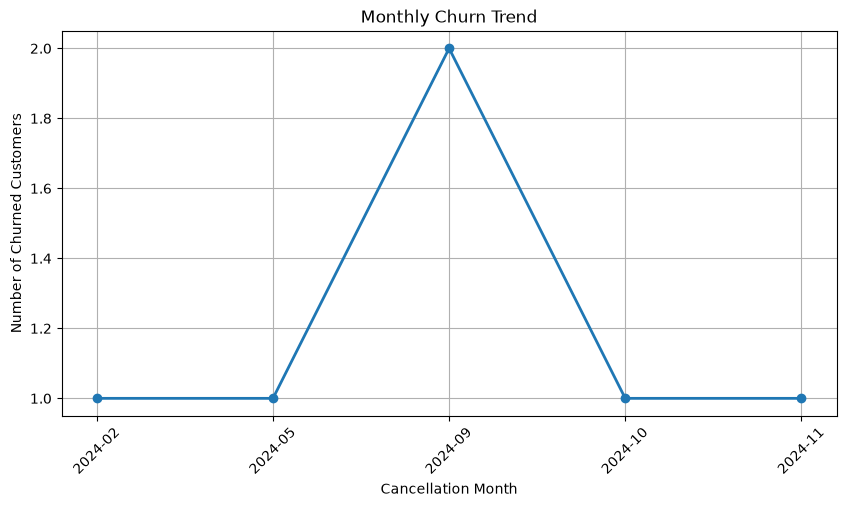

<Figure size 800x300 with 0 Axes>

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_churn["cancellation_month"].astype(str),
    monthly_churn["Churn_Count"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Churn Trend")
plt.xlabel("Cancellation Month")
plt.ylabel("Number of Churned Customers")
plt.xticks(rotation=45)
plt.grid(True)
plt.figure(figsize=(8,3))

plt.show()

In [40]:
churn_by_plan = (
    df_visual[df_visual["cancellation_date"].notna()]
    .groupby("plan_type")
    .size()
    .reset_index(name="Churn_Count")
)

print(churn_by_plan)

  plan_type  Churn_Count
0     Basic            3
1   Premium            1
2  Standard            2


In [41]:
df_visual["churn_flag"] = df_visual["cancellation_date"].notna().astype(int)

churn_rate_plan = (
    df_visual.groupby("plan_type")
    .agg(
        Total_Customers=("customerid", "count"),
        Churned_Customers=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

churn_rate_plan["Churn_Rate"] = (
    churn_rate_plan["Churn_Rate"] * 100
).round(2)

print(churn_rate_plan)

  plan_type  Total_Customers  Churned_Customers  Churn_Rate
0     Basic                5                  3       60.00
1   Premium                7                  1       14.29
2  Standard                9                  2       22.22


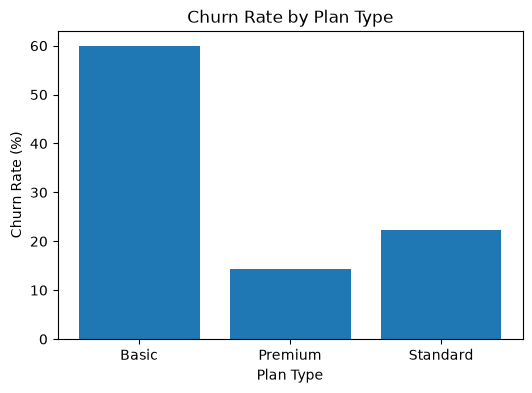

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    churn_rate_plan["plan_type"],
    churn_rate_plan["Churn_Rate"]
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [45]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

In [46]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [47]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [50]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

In [51]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [52]:
df_db_customer = pd.read_sql("SELECT * FROM db_customer", conn)

In [53]:
print(df_db_customer.columns)

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests',
       'pincode'],
      dtype='str')


In [54]:
df_state = pd.merge(
    df_db_customer,
    df_db_subscription,
    on="customerid",
    how="inner"
)

df_state["churn_flag"] = (
    df_state["cancellation_date"].notna().astype(int)
)

In [55]:
churn_by_state = (
    df_state.groupby("state")
    .agg(
        Total_Customers=("customerid", "count"),
        Churned_Customers=("churn_flag", "sum"),
        Churn_Rate=("churn_flag", "mean")
    )
    .reset_index()
)

churn_by_state["Churn_Rate"] = (
    churn_by_state["Churn_Rate"] * 100
).round(2)

print(churn_by_state)

           state  Total_Customers  Churned_Customers  Churn_Rate
0          Delhi                4                  1       25.00
1      Karnataka                2                  2      100.00
2      Kathmandu                2                  0        0.00
3    Maharashtra                3                  0        0.00
4      Meghalaya                3                  2       66.67
5       Nagaland                1                  0        0.00
6      Rajasthan                2                  0        0.00
7      Telangana                2                  1       50.00
8  Uttar Pradesh                2                  0        0.00


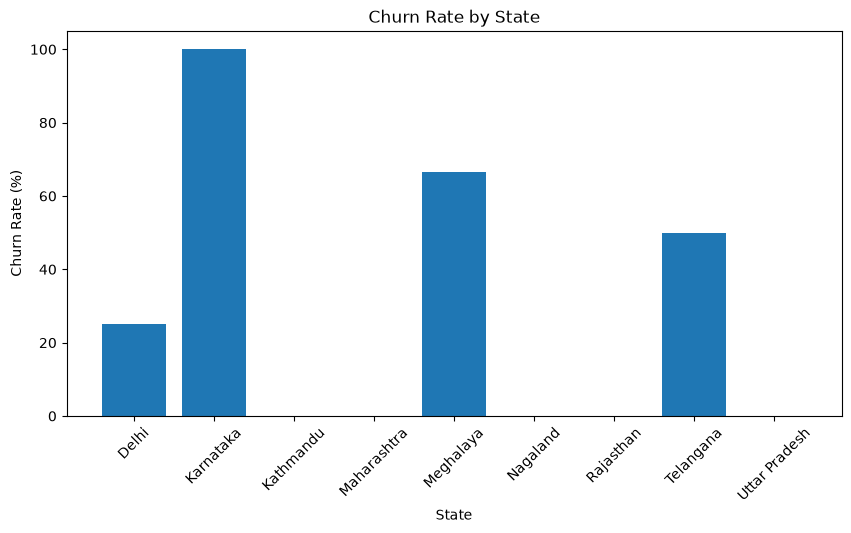

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    churn_by_state["state"],
    churn_by_state["Churn_Rate"]
)

plt.title("Churn Rate by State")
plt.xlabel("State")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [58]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'cancellation_month', 'churn_flag'],
      dtype='str')

In [60]:
print(df_visual.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'cancellation_month', 'churn_flag']


In [61]:
df_visual["churn_risk"] = pd.cut(
    df_visual["churn_score"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [64]:
df_visual[[
    "plan_type",
    "contract_type",
    "churn_score",
    "churn_flag",
    "churn_risk",
    "escalations"
]].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,Low,NaN
1,Premium,Annual,91,1,High,N
2,Premium,Annual,91,1,High,Y
3,Basic,Monthly,34,0,Low,NaN
4,Premium,Annual,8,0,Low,NaN


In [66]:
df_encoded = df_visual.copy()

In [68]:
df_encoded["escalations"] = df_encoded["escalations"].map({"Y": 1, "N": 0})

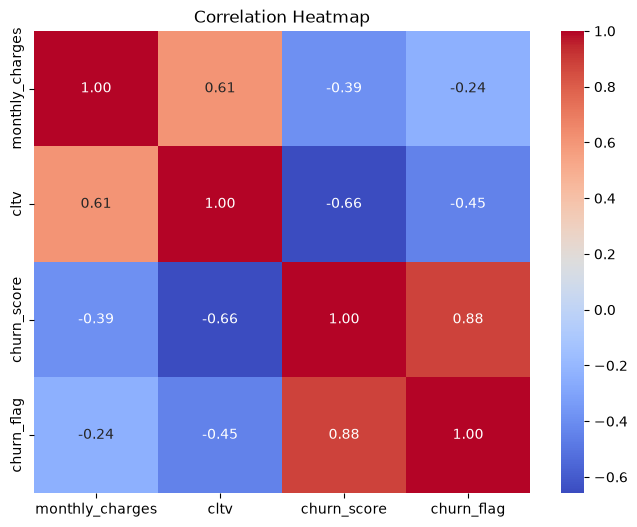

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_visual.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [73]:
df_encoded.dtypes

customerid                            str
subscription_start_date    datetime64[us]
subscription_type                     str
renewal_date               datetime64[us]
plan_type                             str
contract_type                         str
cancellation_date          datetime64[us]
cancellation_reason                   str
monthly_charges                   float64
cltv                                int64
churn_score                         int64
cancellation_month              period[M]
churn_flag                          int64
churn_risk                       category
escalations                       float64
dtype: object

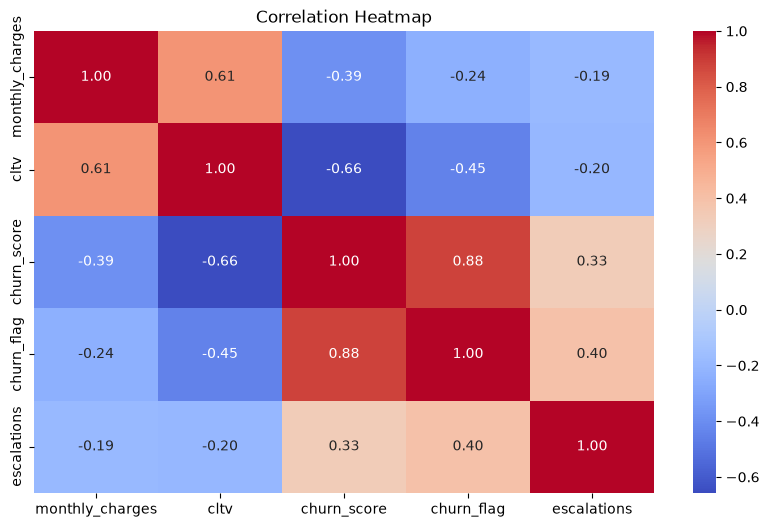

In [74]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

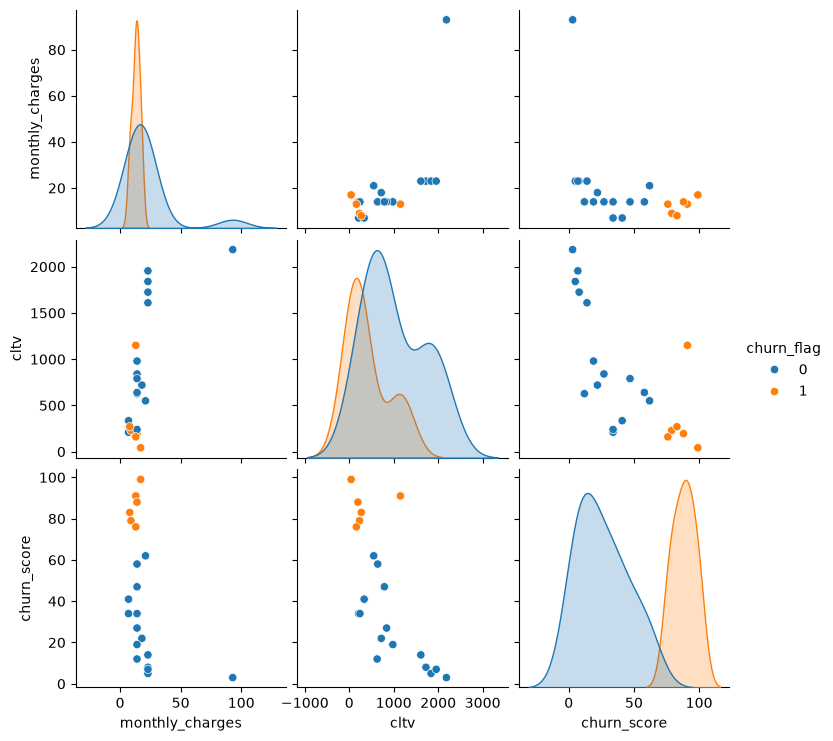

In [77]:
sns.pairplot(
    df_visual[
        [
            "monthly_charges",
            "cltv",
            "churn_score",
            "churn_flag"
        ]
    ],
    hue="churn_flag"
)

plt.show()

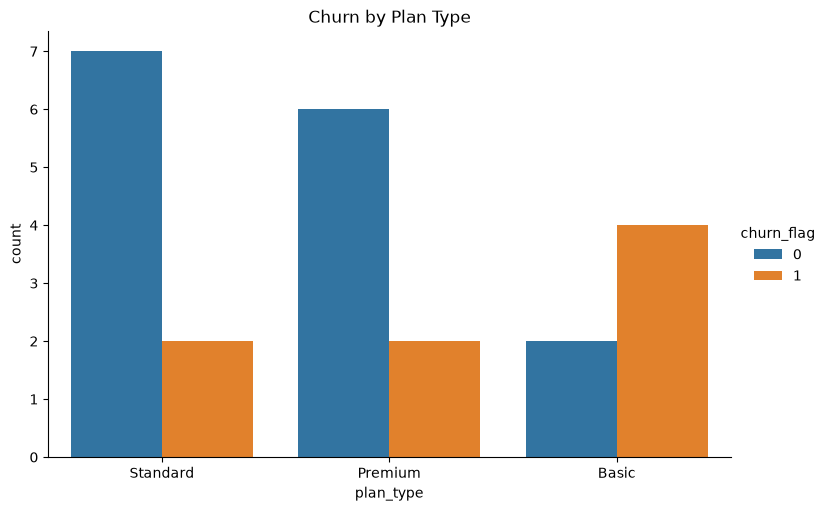

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=df_visual,
    x="plan_type",
    hue="churn_flag",
    kind="count",
    height=5,
    aspect=1.5
)

plt.title("Churn by Plan Type")
plt.show()

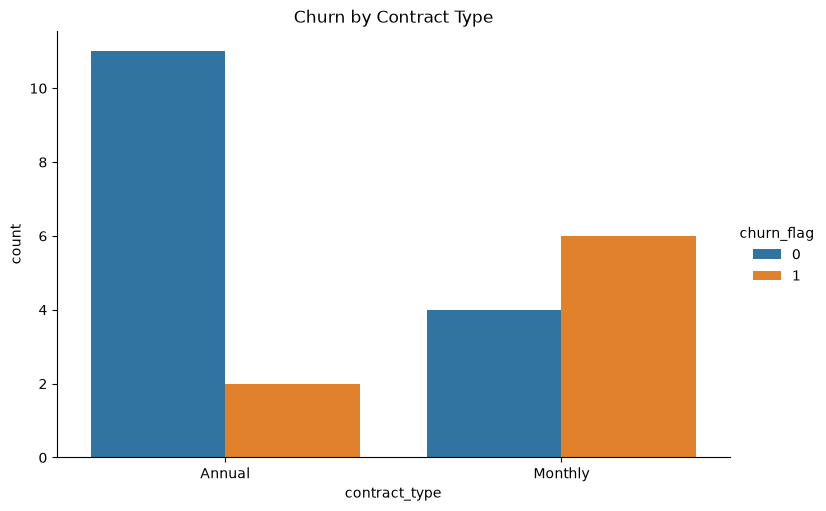

In [79]:
sns.catplot(
    data=df_visual,
    x="contract_type",
    hue="churn_flag",
    kind="count",
    height=5,
    aspect=1.5
)

plt.title("Churn by Contract Type")
plt.show()

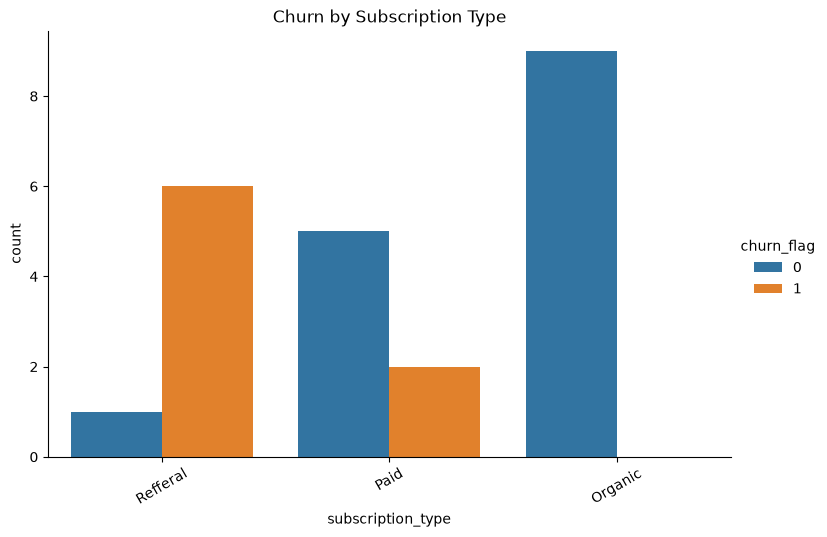

In [80]:
sns.catplot(
    data=df_visual,
    x="subscription_type",
    hue="churn_flag",
    kind="count",
    height=5,
    aspect=1.5
)

plt.title("Churn by Subscription Type")
plt.xticks(rotation=30)
plt.show()

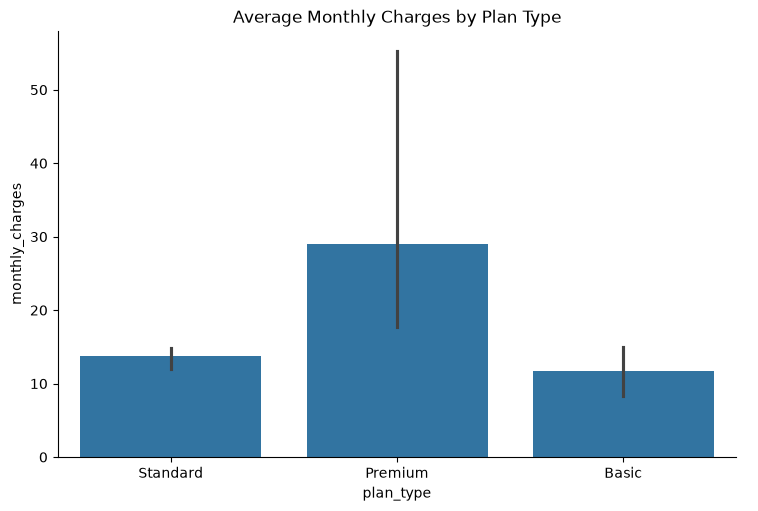

In [81]:
sns.catplot(
    data=df_visual,
    x="plan_type",
    y="monthly_charges",
    kind="bar",
    height=5,
    aspect=1.5
)

plt.title("Average Monthly Charges by Plan Type")
plt.show()

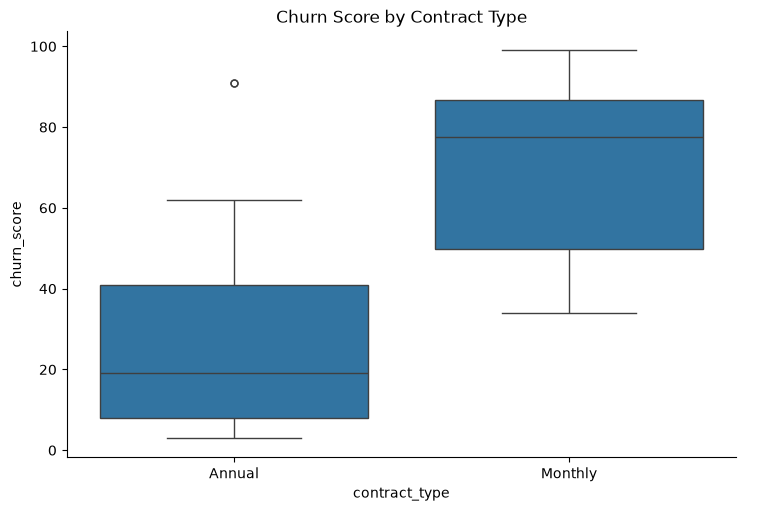

In [82]:
sns.catplot(
    data=df_visual,
    x="contract_type",
    y="churn_score",
    kind="box",
    height=5,
    aspect=1.5
)

plt.title("Churn Score by Contract Type")
plt.show()

In [89]:
pivot = pd.pivot_table(
    df_visual,
    values=["monthly_charges", "customerid", "churn_flag"],
    index="plan_type",
    aggfunc={
        "monthly_charges": "sum",
        "customerid": "nunique",
        "churn_flag": "mean"
    }
)

pivot["churn_flag"] = (pivot["churn_flag"] * 100).round(2)

pivot.rename(columns={
    "customerid": "Total_Customers",
    "monthly_charges": "Revenue",
    "churn_flag": "Churn_Rate (%)"
}, inplace=True)

print(pivot)

           Churn_Rate (%)  Total_Customers  Revenue
plan_type                                          
Basic               66.67                5    69.94
Premium             25.00                7   231.92
Standard            22.22                9   123.91


In [93]:
conn.execute("""
CREATE TABLE IF NOT EXISTS users (
    first_name TEXT,
    country TEXT,
    budget INTEGER
)
""")

conn.commit()

In [94]:
users = [
    ("Tushar", "India", 50000),
    ("Rahul", "India", 35000),
    ("John", "USA", 80000),
    ("Alice", "UK", 65000)
]

conn.executemany("""
INSERT INTO users (first_name, country, budget)
VALUES (?, ?, ?)
""", users)

conn.commit()

In [95]:
import pandas as pd

df = pd.read_sql("SELECT * FROM users", conn)

print(df)

  first_name country  budget
0     Tushar   India   50000
1      Rahul   India   35000
2       John     USA   80000
3      Alice      UK   65000


In [3]:
import os
print(os.getcwd())

C:\Users\tusha


In [4]:
import os

print(os.getcwd())

C:\Users\tusha


In [5]:
import os

print(os.listdir())

['.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.ms-ad', '.streamlit', '.VirtualBox', '.VPNMaster', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'churn analysis.ipynb', 'Cisco Packet Tracer 8.2.2', 'Contacts', 'Cookies', 'csv_ai_agent', 'customer_churn(1).db', 'customer_churn.db', 'Documents', 'Downloads', 'exported_churn_data.csv', 'Favorites', 'from groq import Groq.txt', 'Links', 'Local Settings', 'Microsoft', 'ms-notepad.txt', 'msiexec', 'Music', 'My Documents', 'net', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{ba755516-e5e2-11ef-af93-aa80827ef4e4}.TM.blf', 'NTUSER.DAT{ba755516-e5e2-11ef-af93-aa80827ef4e4}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{ba755516-e5e2-11ef-af93-aa80827ef4e4}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'PycharmProjects', 'Recent', 'sample.csv', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'test_database.sqlite', 

In [7]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\customer_churn(1).db")

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

conn.close()

Empty DataFrame
Columns: [name]
Index: []


In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\customer_churn.db")

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

conn.close()

Empty DataFrame
Columns: [name]
Index: []


In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tusha\exported_churn_data.csv")

print(df.head())
print("\nColumns:")
print(df.columns.tolist())
print("\nShape:", df.shape)

   customerid       complaint_date escalations  csat_score  col_1  \
0  0003-MKNFE  2024-08-28 00:00:00           N          60    NaN   
1  0003-MKNFE  2024-08-28 00:00:00           Y          10    NaN   
2  0013-EXCHZ  2024-01-20 00:00:00           Y          20    NaN   
3  0013-MHZWF  2025-03-18 00:00:00           N          90    NaN   
4  0013-SMEOE  2024-11-01 00:00:00           N          30    NaN   

             comment  complaint_count  
0      service issue                2  
1     demaned refund                2  
2                NaN                1  
3  guidance to renew                1  
4                NaN                1  

Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment', 'complaint_count']

Shape: (9, 7)


In [11]:
%whos

Variable   Type          Data/Info
----------------------------------
conn       Connection    <sqlite3.Connection object at 0x0000025DA2816980>
df         DataFrame     Shape: (9, 7)
os         module        <module 'os' (frozen)>
pd         module        <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
sqlite3    module        <module 'sqlite3' from 'C<...>b\\sqlite3\\__init__.py'>
tables     DataFrame     Shape: (0, 1)


In [12]:
print(conn.execute("PRAGMA database_list;").fetchall())

ProgrammingError: Cannot operate on a closed database.

In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

              name
0      db_customer
1  db_subscription
2       db_support


In [14]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\tusha\Downloads\customer_churn.db")

# Read tables
df_customer = pd.read_sql("SELECT * FROM db_customer", conn)
df_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)
df_support = pd.read_sql("SELECT * FROM db_support", conn)

# Export CSV
df_customer.to_csv(r"C:\Users\tusha\Downloads\db_customer.csv", index=False)
df_subscription.to_csv(r"C:\Users\tusha\Downloads\db_subscription.csv", index=False)
df_support.to_csv(r"C:\Users\tusha\Downloads\db_support.csv", index=False)

conn.close()

print("✅ Export Successful")

✅ Export Successful
